In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [4]:
path = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/fargo_fiducial_2gen"
paths = [path]



In [5]:
max_n =100
rho_cube=[] # first index: which path, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in range(max_n+1):
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

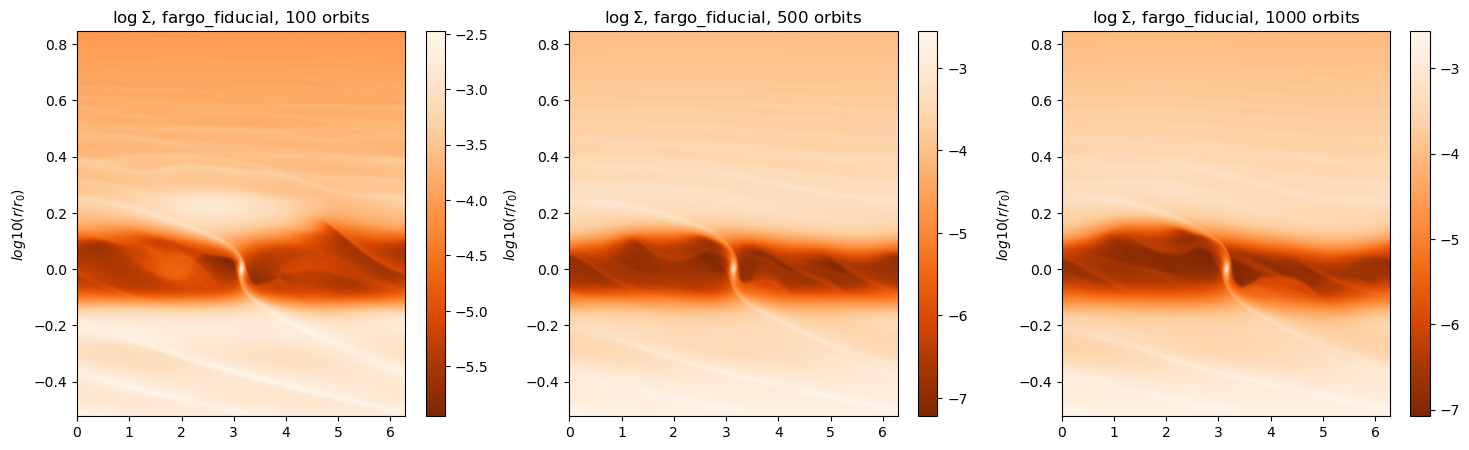

In [14]:
%matplotlib inline
r_min = 0.3
r_max = 7

frames = [10,50,100]

for i in range(len(paths)):
    plt.figure(figsize=(6*len(frames),5))
    for it,frame in enumerate(frames):
        plt.subplot(1,len(frames),it+1)
        plt.imshow(np.log10(rho_cube[0][frame]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])
        plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frame)*10} orbits")
        plt.ylabel("$log10(r/r_0)$")
        plt.colorbar()


In [15]:

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

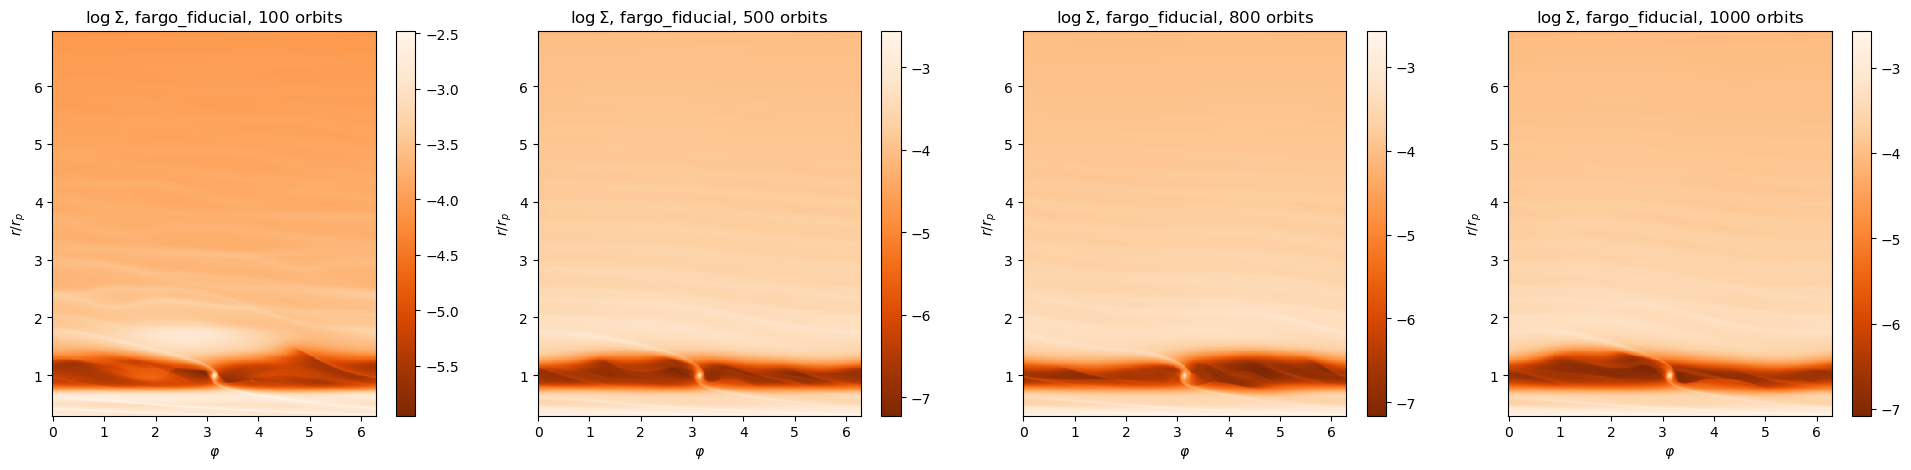

In [19]:
%matplotlib inline
r_min = 0.3
r_max = 7

frames = [10,50,80,100]

for i in range(len(paths)):
    plt.figure(figsize=(6*len(frames),5))
    for it,frame in enumerate(frames):
        plt.subplot(1,len(frames),it+1)
        plt.pcolormesh(PHI, R, np.log10(rho_cube[i][frame]),cmap=cm.Oranges_r, shading='auto')
        plt.xlabel("$\\varphi$")
        plt.ylabel("$r/r_p$")
        plt.title(f"$\\log \\Sigma$, {path[43:-5]}, {(frame)*10} orbits")
        plt.colorbar()

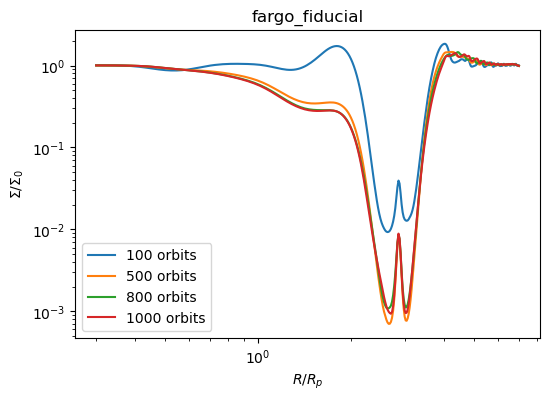

In [25]:

rlist = np.linspace(r_min,r_max, len(rho_cube[0][0]))
# average surface density at radius r
rho_mean = np.mean(rho_cube, axis=3)

frames = [10,50,80,100]

for i in range(len(paths)):
    plt.figure(figsize=(6,4))
    plt.xlabel("$R/R_p$")
    plt.ylabel("$\\Sigma/\\Sigma_0$")
    plt.xscale("log")
    plt.yscale("log")

    plt.title(path[43:-5])
    for it,frame in enumerate(frames):
        plt.plot(rlist,rho_mean[i][frame]/rho_mean[i][0], label=f"{frame*10} orbits")
        
    plt.legend()


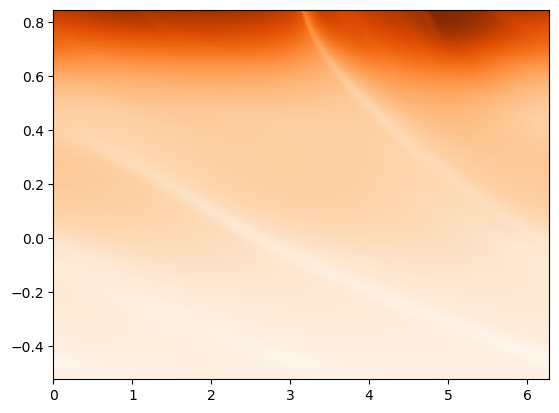

In [35]:
#plt.imshow(np.log10(rho_cube[0][-1][:100,:]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)])
# looks fine at the lower edge; I don't think more resolution is needed.